<font size="6"><b>Projet Seattle - Prédiction des émissions totales de CO<sub>2</sub> des bâtiments non résidentiels</b></font>

# 1. Simulation de modèles et choix du modèle final

## 1.0. Setup & chargement des données

Cette première section initialise l'environnement de travail, charge le dataset final préparé dans le notebook d'analyse exploratoire, puis met en place la séparation **features / cible** et le découpage **train / test**.

Dans ce notebook, on se concentre sur la prédiction des **émissions totales de CO<sub>2</sub>** via la cible `TotalGHGEmissions`.

In [1]:
# Imports de base

import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_validate, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Options d'affichage pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Style des graphiques
sns.set(style="whitegrid")


# Chargement des données
df = pd.read_csv("data_model_final.csv")

print("Dataset chargé :", df.shape)
df.head()

Dataset chargé : (1402, 104)


,OSEBuildingID,ZipCode,CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions,MainUses_GFA_Ratio,Use_Adult Education,Use_Automobile Dealership,Use_Bank Branch,Use_Bar/Nightclub,Use_College/University,Use_Convenience Store without Gas Station,Use_Courthouse,Use_Data Center,Use_Distribution Center,Use_Enclosed Mall,Use_Fast Food Restaurant,Use_Financial Office,Use_Fire Station,Use_Fitness Center/Health Club/Gym,Use_Food Sales,Use_Food Service,Use_Hospital (General Medical & Surgical),Use_Hotel,Use_K-12 School,Use_Laboratory,Use_Library,Use_Lifestyle Center,Use_Manufacturing/Industrial Plant,Use_Medical Office,Use_Movie Theater,Use_Multifamily Housing,Use_Museum,Use_Non-Refrigerated Warehouse,Use_Office,Use_Other,Use_Other - Education,Use_Other - Entertainment/Public Assembly,Use_Other - Lodging/Residential,...,Use_Other - Services,Use_Other - Technology/Science,Use_Other - Utility,Use_Other/Specialty Hospital,Use_Parking,Use_Performing Arts,"Use_Personal Services (Health/Beauty, Dry Cleaning, etc)",Use_Police Station,Use_Pre-school/Daycare,Use_Refrigerated Warehouse,"Use_Repair Services (Vehicle, Shoe, Locksmith, etc)",Use_Residence Hall/Dormitory,Use_Residential Care Facility,Use_Restaurant,Use_Retail Store,Use_Self-Storage Facility,Use_Senior Care Community,Use_Social/Meeting Hall,Use_Strip Mall,Use_Supermarket/Grocery Store,Use_Swimming Pool,Use_Urgent Care/Clinic/Other Outpatient,Use_Vocational School,Use_Worship Facility,BuildingAge,Ratio_Parking_GFA,Ratio_Building_GFA,Ratio_LargestUse_GFA,Ratio_SecondaryUses_GFA,BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,BuildingType_SPS-District K-12,Neighborhood_Ballard,Neighborhood_CENTRAL,Neighborhood_Central,Neighborhood_DELRIDGE,Neighborhood_DOWNTOWN,Neighborhood_Delridge,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_North,Neighborhood_Northwest,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
0,1,"98,101.00",7,47.61,-122.34,1.00,12,88434,0,88434,"88,434.00",0.00,0.00,60.00,"7,226,362.50",249.98,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,0.00,1.00,1.00,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2,"98,101.00",7,47.61,-122.33,1.00,11,103566,15064,88502,"83,880.00","15,064.00","4,622.00",61.00,"8,387,933.00",295.86,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,20,0.15,0.85,0.81,0.19,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3,"98,101.00",7,47.61,-122.34,1.00,41,956110,196718,759392,"756,493.00",0.00,0.00,43.00,"72,587,024.00","2,089.28",0.79,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,47,0.21,0.79,0.79,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,5,"98,101.00",7,47.61,-122.34,1.00,10,61320,0,61320,"61,320.00",0.00,0.00,56.00,"6,794,584.00",286.43,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,0.00,1.00,1.00,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,8,"98,121.00",7,47.61,-122.34,1.00,18,175580,62000,113580,"123,445.00","68,009.00",0.00,75.00,"14,172,606.00",505.01,1.09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,36,0.35,0.65,0.70,0.39,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


<font size="4"><b>Séparation features / cible</b></font>

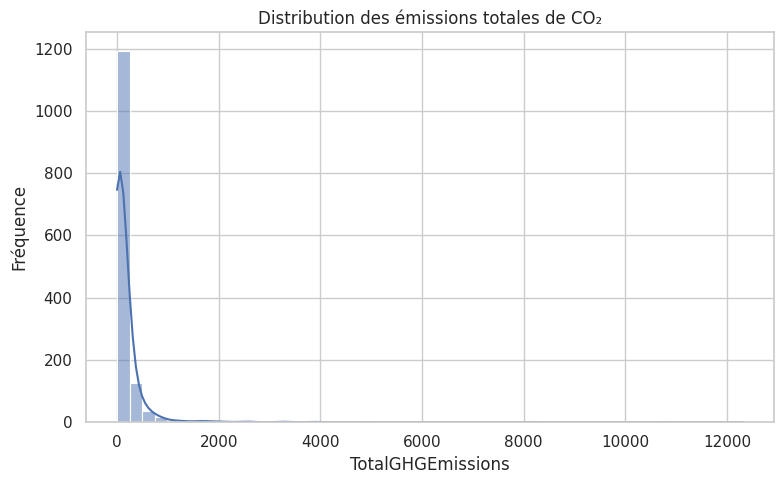

In [2]:
# Définition de la cible
TARGET = "TotalGHGEmissions"

plt.figure(figsize=(8, 5))

sns.histplot(df[TARGET], bins=50, kde=True)

plt.title("Distribution des émissions totales de CO₂")
plt.xlabel("TotalGHGEmissions")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()

La variable cible `TotalGHGEmissions` présente une forte asymétrie à droite, avec la présence de bâtiments très énergivores.  
Afin de réduire l'influence de ces valeurs extrêmes et de faciliter l'apprentissage du modèle, une transformation logarithmique de type `log1p` est appliquée à la cible.

In [3]:
# Définition des features à exclure
features_to_exclude = ["SiteEnergyUse(kBtu)", "ENERGYSTARScore"]

# Séparation X / y
X = df.drop(columns=[TARGET] + features_to_exclude, errors="ignore")
y = np.log1p(df[TARGET])

print("X :", X.shape)
print("y :", y.shape)

X : (1402, 101)
y : (1402,)


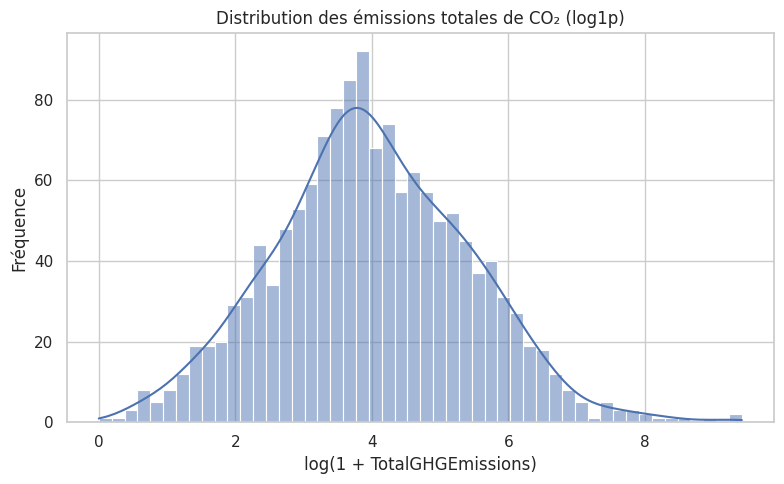

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(np.log1p(df[TARGET]), bins=50, kde=True)

plt.title("Distribution des émissions totales de CO₂ (log1p)")
plt.xlabel("log(1 + TotalGHGEmissions)")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()

<font size="4"><b>Découpage train / test</b></font>

In [5]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (1121, 101) (1121,)
Test  : (281, 101) (281,)


In [6]:
# Vérification rapide : valeurs manquantes
na_rate = X_train.isna().mean().sort_values(ascending=False)
display(na_rate[na_rate > 0].head(10))

,0


## 1.1. Rappel du modèle de référence (benchmark)

<font size="4"><b>Objectif</b></font>

Cette section rappelle le **modèle de référence retenu à l'issue de l'analyse exploratoire**.

Le modèle Ridge sert ici de **baseline robuste** pour comparer équitablement les performances des modèles plus complexes testés par la suite.

<br>

<font size="4"><b>Modèle retenu</b></font>

- **Algorithme :** Ridge Regression
- **Pipeline :**
  - Imputation des valeurs manquantes
  - Standardisation des variables
  - Régression Ridge
- **Rôle :** point de comparaison officiel (benchmark), non remis en question dans cette étape.

<br>

<font size="4"><b>Définition du pipeline Ridge</b></font>

In [7]:
ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

<font size="4"><b>Évaluation par validation croisée</b></font>

In [8]:
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

scores_ridge = cross_validate(
    ridge_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

ridge_results = {
    "Model": "Ridge (benchmark)",
    "R2_CV": np.mean(scores_ridge["test_r2"]),
    "MAE_CV": -np.mean(scores_ridge["test_mae"]),
    "RMSE_CV": np.mean(np.sqrt(-scores_ridge["test_mse"]))
}

pd.DataFrame([ridge_results])

,Model,R2_CV,MAE_CV,RMSE_CV
0,Ridge (benchmark),0.36,0.87,1.15


<font size="4"><b>Conclusion</b></font>

Le modèle Ridge constitue une **référence solide et interprétable**, permettant d'évaluer les gains réels apportés par des modèles non linéaires,

→ Les sections suivantes compareront systématiquement leurs performances à ce benchmark.

## 1.2. Modèle SVM (Support Vector Regression)

<font size="4"><b>Objectif</b></font>

Tester un **modèle non linéaire** capable de capturer des relations complexes entre les variables explicatives et la consommation énergétique, que les modèles linéaires (Ridge/Lasso) ne peuvent pas modéliser.

Le **SVR** est particulièrement adapté :
- aux relations non linéaires,
- aux données de dimension relativement élevée,
- à condition d'avoir des variables **normalisées**.

<br>

<font size="4"><b>Choix méthodologiques</b></font>

- **Standardisation obligatoire** (sensibilité du SVM à l'échelle des variables).
- **Recherche d'hyperparamètres limitée** pour maîtriser le temps de calcul.
- **`RandomizedSearchCV`** privilégié plutôt qu'une `GridSearch` exhaustive.
- **Validation croisée** avec les mêmes métriques que le benchmark Ridge.

In [9]:
# Pipeline SVM
svr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVR())
])

<font size="4"><b>Recherche d'hyperparamètres</b></font>

In [10]:
# Définition de l'espace de recherche des hyperparamètres du SVR
param_distributions = {
    "model__kernel": ["rbf"],
    "model__C": [1, 10, 50, 100],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__epsilon": [0.1, 0.2, 0.5]
}

# Mise en place de la recherche aléatoire d'hyperparamètres
svr_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=param_distributions,
    n_iter=36,
    cv=5,
    scoring=scoring,
    refit="mse",
    random_state=42,
    n_jobs=-1
)

Les valeurs d'hyperparamètres du SVR ont été choisies dans des plages standards et raisonnables, afin de tester efficacement la capacité d'un modèle à noyau à améliorer la prédiction par rapport au modèle linéaire de référence, sans chercher une optimisation exhaustive ni augmenter excessivement le temps de calcul.

<font size="4"><b>Entraînement et évaluation</b></font>

In [11]:
svr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('scaler', StandardScaler()),
                                             ('model', SVR())]),
                   n_iter=36, n_jobs=-1,
                   param_distributions={'model__C': [1, 10, 50, 100],
                                        'model__epsilon': [0.1, 0.2, 0.5],
                                        'model__gamma': ['scale', 0.01, 0.1],
                                        'model__kernel': ['rbf']},
                   random_state=42, refit='mse',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [12]:
# Récupération du meilleur modèle et de ses scores CV
best_svr = svr_search.best_estimator_
best_idx = svr_search.best_index_
cvres = svr_search.cv_results_

svr_results = {
    "Model": "SVR",
    "Best_params_kernel": svr_search.best_params_["model__kernel"],
    "Best_params_C": svr_search.best_params_["model__C"],
    "Best_params_gamma": svr_search.best_params_["model__gamma"],
    "Best_params_epsilon": svr_search.best_params_["model__epsilon"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([svr_results])

,Model,Best_params_kernel,Best_params_C,Best_params_gamma,Best_params_epsilon,R2_CV,MAE_CV,RMSE_CV
0,SVR,rbf,10,0.01,0.50,0.46,0.82,1.05


<font size="4"><b>Interprétation des performances du modèle SVM (SVR)</b></font>

Le modèle **SVR** testé avec un noyau **RBF** présente des performances **supérieures** au modèle de référence **Ridge** sur la prédiction des émissions de CO<sub>2</sub>.

- Le **R² CV ≈ 0.46** indique une **meilleure capacité explicative** que le modèle Ridge (≈ 0.36), suggérant que le SVR capte davantage les relations non linéaires entre les caractéristiques des bâtiments et leurs émissions.
- Les **erreurs MAE et RMSE** sont également **plus faibles** que celles du Ridge, traduisant une amélioration globale de la qualité des prédictions.
- Le choix d'un noyau **RBF**, avec une régularisation modérée (`C = 10`), un `gamma = 0.01` et un `epsilon = 0.5`, semble **adapté à la structure des données**, permettant au modèle de mieux gérer la complexité des émissions de CO<sub>2</sub>.

<br>

<font size="4"><b>Comparaison avec le modèle de référence (Ridge)</b></font>

- **Ridge (benchmark)**
  - R² CV ≈ **0.36**
  - MAE CV ≈ **0.87**
  - RMSE CV ≈ **1.15**

- **SVR**
  - R² CV ≈ **0.46**
  - MAE CV ≈ **0.82**
  - RMSE CV ≈ **1.05**

Le modèle SVR **améliore les performances sur l'ensemble des métriques**, avec un gain notable en R² et une réduction des erreurs moyennes.

<br>

<font size="4"><b>Décision</b></font>

- Le modèle **SVR est conservé comme candidat sérieux** pour la suite du projet.
- Le modèle **Ridge reste le benchmark de référence**, servant de point de comparaison stable et interprétable.

→ Les prochains tests se concentreront sur des **modèles d'ensemble** (Random Forest, Gradient Boosting), afin d'évaluer si des approches plus flexibles permettent d'améliorer davantage la prédiction des émissions de CO<sub>2</sub>.

## 1.3. Modèle Random Forest

### 1.3.1. Introduction

L'objectif de cette section est de tester un **modèle d'ensemble non linéaire**, basé sur des arbres de décision, afin de capturer des relations complexes entre les variables explicatives et les émissions de CO<sub>2</sub>.

Les **Random Forests** permettent :
- de réduire la variance par agrégation de plusieurs arbres,
- de modéliser naturellement des **interactions non linéaires**,
- de gérer des jeux de données hétérogènes sans normalisation préalable.

Ce modèle constitue un bon compromis entre **performance**, **robustesse** et **interprétabilité**.

### 1.3.2. Pipeline Random Forest

Contrairement aux modèles linéaires ou au SVR :
- **pas de standardisation nécessaire**,
- l'imputation reste toutefois indispensable.

In [13]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

### 1.3.3. Hyperparamètres testés

On se concentre sur les hyperparamètres **ayant le plus d'impact**, sans chercher un réglage fin.

In [14]:
param_distributions_rf = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 5, 10]
}

### 1.3.4. Recherche d'hyperparamètres

On privilégie ici **`RandomizedSearchCV`** pour limiter le temps de calcul.

In [15]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions_rf,
    n_iter=10,
    cv=5,
    scoring=scoring,
    refit="mse",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 5, 10],
                                        'model__n_estimators': [100, 300, 500]},
                   random_state=42, refit='mse',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'})

### 1.3.5. Résultats du Random Forest

In [16]:
# Récupération du meilleur modèle et de ses scores CV
best_rf = rf_search.best_estimator_
best_idx = rf_search.best_index_
cvres = rf_search.cv_results_

rf_results = {
    "Model": "Random Forest",
    "Best_n_estimators": rf_search.best_params_["model__n_estimators"],
    "Best_max_depth": rf_search.best_params_["model__max_depth"],
    "Best_min_samples_leaf": rf_search.best_params_["model__min_samples_leaf"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([rf_results])

,Model,Best_n_estimators,Best_max_depth,Best_min_samples_leaf,R2_CV,MAE_CV,RMSE_CV
0,Random Forest,300,10,5,0.50,0.80,1.01


<font size="4"><b>Interprétation des résultats - Random Forest vs Ridge</b></font>

Le modèle **Random Forest** surpasse nettement le modèle **Ridge**, avec un **R² en validation croisée de 0,50 contre 0,36** pour Ridge. Cette progression indique une **meilleure capacité à modéliser les relations complexes et non linéaires** entre les variables explicatives et les émissions de CO<sub>2</sub>.

Cette amélioration du pouvoir explicatif s'accompagne également d'une **réduction des erreurs** :
- le **RMSE est plus faible** que celui du Ridge, traduisant une amélioration globale de la précision des prédictions ;
- le **MAE est également inférieur**, ce qui indique que le modèle fournit des estimations plus proches des valeurs réelles sur la majorité des bâtiments.

Ces résultats montrent que :
- le Random Forest capture plus efficacement la **structure globale des données** liées aux émissions ;
- il est **plus adapté qu'un modèle linéaire** pour modéliser les effets combinés de la taille, de l'usage et des caractéristiques des bâtiments.

Le modèle apparaît ainsi **plus flexible et plus performant**, tout en conservant un bon équilibre entre biais et variance grâce aux mécanismes d'agrégation propres aux forêts aléatoires.

<br>

<font size="4"><b>Conclusion</b></font>

Le **Random Forest devient un candidat sérieux** pour la suite du projet, offrant un **gain significatif et cohérent** par rapport au modèle Ridge, aussi bien en termes de **capacité explicative** que de **qualité des prédictions**.

Une comparaison avec les performances du **Gradient Boosting** permettra de déterminer si un modèle séquentiel peut encore améliorer ce compromis avant de retenir un modèle final.

<br>

<font size="4"><b>Point de vigilance</b></font>

> Les Random Forests peuvent obtenir de très bonnes performances sur les données d'entraînement, mais présentent un risque de surapprentissage si les arbres sont trop profonds ou insuffisamment régularisés. Une comparaison systématique des performances en validation croisée est donc indispensable pour juger de leur capacité de généralisation.

## 1.4. Modèle Gradient Boosting

### 1.4.1. Introduction

L'objectif est de tester un modèle de **boosting**, qui combine plusieurs arbres construits **séquentiellement** : chaque nouvel arbre corrige une partie des erreurs du précédent.  
Le Gradient Boosting est souvent très performant sur des données tabulaires et peut capturer des relations non linéaires tout en limitant la complexité via ses hyperparamètres (profondeur, learning rate…).

### 1.4.2. Pipeline Gradient Boosting

Pas besoin de scaling, mais on garde l'imputation pour les valeurs manquantes.

In [17]:
gbr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

### 1.4.3. Recherche d'hyperparamètres

On teste une grille volontairement courte, centrée sur les paramètres les plus importants :
- `n_estimators` : nombre d'arbres (capacité)
- `learning_rate` : contribution de chaque arbre (régularisation)
- `max_depth` : complexité de chaque arbre (risque d'overfit)

In [18]:
param_distributions_gbr = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4]
}

### 1.4.4. `RandomizedSearchCV` + validation croisée

In [19]:
gbr_search = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=param_distributions_gbr,
    n_iter=10,
    cv=5,
    scoring=scoring,
    refit="mse",
    random_state=42,
    n_jobs=-1
)

gbr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [2, 3, 4],
                                        'model__n_estimators': [100, 300, 500]},
                   random_state=42, refit='mse',
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'})

### 1.4.5. Résultats du Gradient Boosting

In [20]:
best_gbr = gbr_search.best_estimator_
best_idx = gbr_search.best_index_
cvres = gbr_search.cv_results_

gbr_results = {
    "Model": "Gradient Boosting",
    "Best_n_estimators": gbr_search.best_params_["model__n_estimators"],
    "Best_learning_rate": gbr_search.best_params_["model__learning_rate"],
    "Best_max_depth": gbr_search.best_params_["model__max_depth"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([gbr_results])

,Model,Best_n_estimators,Best_learning_rate,Best_max_depth,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting,100,0.10,3,0.52,0.79,1.00


<font size="4"><b>Interprétation des résultats du Gradient Boosting</b></font>

Le modèle **Gradient Boosting** améliore nettement les performances par rapport au modèle de référence Ridge sur l'ensemble des métriques :
- Le **R² augmente significativement** (≈ **0,52** contre **0,36**), traduisant une capacité accrue à expliquer la variance des émissions de CO<sub>2</sub>.
- Le **MAE diminue également**, indiquant des erreurs absolues moyennes plus faibles et des prédictions globalement plus précises.
- Le **RMSE est lui aussi inférieur**, ce qui suggère une meilleure gestion des erreurs importantes, y compris pour les bâtiments les plus émetteurs.

Ces résultats montrent que le Gradient Boosting **capture efficacement les relations non linéaires et les interactions complexes** entre les variables explicatives, tout en conservant une bonne capacité de généralisation grâce à des hyperparamètres maîtrisés (`learning_rate = 0.1`, `max_depth = 3`).

L'amélioration est **cohérente sur l'ensemble des métriques**, ce qui positionne clairement le Gradient Boosting comme un **candidat très solide pour le modèle final**, à comparer directement avec le Random Forest lors de la synthèse globale.

<br>

<font size="4"><b>Point de vigilance</b></font>

> Le Gradient Boosting peut **overfitter rapidement** si :
> - trop d'arbres,
> - arbres trop profonds,
> - learning_rate trop élevé.

## 1.5. Comparaison globale des modèles et choix du modèle final

### 1.5.1. Comparaison des performances des modèles

**Objectif**

Comparer l'ensemble des modèles testés sur des métriques homogènes afin d'identifier celui offrant le meilleur compromis entre performance, robustesse et complexité.

In [21]:
# Harmonisation des résultats
comparison_df = pd.DataFrame([
    {
        "Model": ridge_results["Model"],
        "R2_CV": ridge_results["R2_CV"],
        "MAE_CV": ridge_results["MAE_CV"],
        "RMSE_CV": ridge_results["RMSE_CV"]
    },
    {
        "Model": svr_results["Model"],
        "R2_CV": svr_results["R2_CV"],
        "MAE_CV": svr_results["MAE_CV"],
        "RMSE_CV": svr_results["RMSE_CV"]
    },
    {
        "Model": rf_results["Model"],
        "R2_CV": rf_results["R2_CV"],
        "MAE_CV": rf_results["MAE_CV"],
        "RMSE_CV": rf_results["RMSE_CV"]
    },
    {
        "Model": gbr_results["Model"],
        "R2_CV": gbr_results["R2_CV"],
        "MAE_CV": gbr_results["MAE_CV"],
        "RMSE_CV": gbr_results["RMSE_CV"]
    }
]).sort_values("RMSE_CV")

comparison_df

,Model,R2_CV,MAE_CV,RMSE_CV
3,Gradient Boosting,0.52,0.79,1.00
2,Random Forest,0.50,0.80,1.01
1,SVR,0.46,0.82,1.05
0,Ridge (benchmark),0.36,0.87,1.15


<font size="4"><b>Lecture rapide des résultats</b></font>

- **Ridge (benchmark)**  
  Sert de **référence linéaire robuste**. Il fournit des performances correctes mais limitées, confirmant que la relation entre les variables explicatives et les émissions de CO<sub>2</sub> présente des **non-linéarités** que le modèle ne peut pleinement capturer.

- **Gradient Boosting**  
  Présente les **meilleures performances globales**, avec le **R² le plus élevé**, ainsi que les **plus faibles MAE et RMSE**. Cela indique une excellente capacité à modéliser des relations complexes tout en maintenant des erreurs globalement maîtrisées, y compris pour les bâtiments les plus émetteurs.

- **Random Forest**  
  Offre également une **forte capacité explicative**, avec un R² proche de celui du Gradient Boosting, mais reste légèrement en retrait. Son **RMSE légèrement plus élevé** suggère une dispersion des erreurs un peu plus importante, traduisant une généralisation légèrement moins précise.

- **SVR**  
  Améliore les performances par rapport au modèle Ridge, montrant sa capacité à capturer certaines non-linéarités. Toutefois, ses performances restent **inférieures à celles des modèles d'ensemble**, ce qui en fait un candidat moins compétitif dans ce contexte.

### 1.5.2. Choix du modèle final

Les résultats mettent en évidence des **différences nettes de performance et de comportement** entre les modèles testés.
- **Gradient Boosting** se distingue comme le **meilleur modèle global**, avec :
  - le **R² le plus élevé**, indiquant la meilleure capacité à expliquer la variance des émissions de CO<sub>2</sub> ;
  - les **plus faibles MAE et RMSE**, traduisant des prédictions à la fois **précises en moyenne** et **robustes face aux valeurs d'émissions les plus élevées**.

  Ces résultats montrent que le modèle parvient à capturer efficacement les relations complexes entre les caractéristiques des bâtiments et leurs émissions de CO<sub>2</sub>, tout en maintenant une bonne stabilité des erreurs.
- **Random Forest** affiche également de bonnes performances, avec un R² élevé, mais reste **légèrement en retrait** par rapport au Gradient Boosting. Son RMSE plus important suggère une **dispersion des erreurs plus forte**, traduisant une sensibilité accrue à certains profils de bâtiments.
- **SVR** et **Ridge** fournissent des performances inférieures, confirmant que des modèles plus flexibles sont nécessaires pour exploiter pleinement la structure des données.

Compte tenu de ces éléments, **le modèle retenu est le Gradient Boosting**, car il offre le **meilleur compromis entre capacité explicative, précision des prédictions et stabilité globale**, en adéquation avec les enjeux métier liés à l'estimation fiable des émissions de CO<sub>2</sub> des bâtiments.

<br>

<font size="4"><b>Potentiel d'amélioration</b></font>

Le **Gradient Boosting** présente également un **fort potentiel d'amélioration** grâce à la richesse de ses hyperparamètres, qui permettent un ajustement fin du compromis biais-variance. Une optimisation plus approfondie (recherche aléatoire élargie ou grille ciblée) pourrait encore améliorer ses performances tout en conservant un bon niveau de généralisation, ce qui en fait un choix particulièrement pertinent pour la suite du projet.

## 1.6. Test du Gradient Boosting sur un jeu de variables réduit

Avant d'optimiser finement les hyperparamètres, on teste si le **feature engineering "réduit"** (1 variable de surface + ratios structurants) permet au Gradient Boosting d'obtenir des performances **comparables ou meilleures**, tout en simplifiant le modèle et en réduisant la redondance entre variables de surface.

### 1.6.1. Construction du jeu de features réduit

In [22]:
# Variables représentant la structure du bâtiment
surface_features_reduced = [
    "PropertyGFATotal",
    "Ratio_Parking_GFA",
    "Ratio_LargestUse_GFA",
    "Ratio_SecondaryUses_GFA"
]

# Toutes les autres variables non liées aux surfaces
other_features = [
    col for col in X_train.columns
    if (
        "GFA" not in col
        and "Ratio" not in col
    )
]

X_train_reduced = X_train[other_features + surface_features_reduced]
X_test_reduced  = X_test[other_features + surface_features_reduced]

print("X_train original :", X_train.shape)
print("X_train réduit   :", X_train_reduced.shape)

X_train original : (1121, 101)
X_train réduit   : (1121, 94)


### 1.6.2. Validation croisée du Gradient Boosting sur features réduites

On réutilise le **meilleur Gradient Boosting trouvé** précédemment (afin de comparer "à hyperparamètres constants"), mais en l'entraînant sur le jeu de variables réduit.

In [23]:
# Reprise des meilleurs hyperparamètres déjà trouvés
gbr_best_params = gbr_search.best_params_

gbr_pipeline_reduced = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        random_state=42,
        n_estimators=gbr_best_params["model__n_estimators"],
        learning_rate=gbr_best_params["model__learning_rate"],
        max_depth=gbr_best_params["model__max_depth"],
    ))
])

scores = cross_validate(
    gbr_pipeline_reduced,
    X_train_reduced,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

gbr_reduced_results = {
    "Model": "Gradient Boosting (features réduites)",
    "R2_CV": np.mean(scores["test_r2"]),
    "MAE_CV": -np.mean(scores["test_mae"]),
    "RMSE_CV": np.sqrt(-np.mean(scores["test_mse"]))
}

# Comparaison rapide avec le Gradient Boosting complet
gbr_full_results = {
    "Model": "Gradient Boosting (features complètes)",
    "R2_CV": gbr_results["R2_CV"],
    "MAE_CV": gbr_results["MAE_CV"],
    "RMSE_CV": gbr_results["RMSE_CV"]
}

pd.DataFrame([gbr_full_results, gbr_reduced_results]).sort_values("RMSE_CV")

,Model,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting (features complètes),0.52,0.79,1.00
1,Gradient Boosting (features réduites),0.51,0.79,1.00


### 1.6.3. Interprétation & décision

La comparaison entre le **Gradient Boosting entraîné sur l'ensemble complet** des features et sur le **jeu de variables réduit** montre des **performances très proches**, avec des écarts faibles sur l'ensemble des métriques.
- Le **R² en validation croisée** est très légèrement supérieur avec le **jeu de features complet**, mais la différence reste marginale.
- Le **MAE** et le **RMSE** présentent également des valeurs quasiment équivalentes entre les deux configurations, sans amélioration significative liée à la réduction du nombre de variables.
- Globalement, les deux approches offrent un **niveau de performance comparable**, traduisant une bonne capacité du modèle à exploiter différents niveaux de détail de l'information.

Ces résultats indiquent que le **Gradient Boosting est capable d'exploiter efficacement les variables disponibles pour expliquer les émissions de CO<sub>2</sub>**, et que la suppression des variables détaillées n'apporte pas de gain de performance notable.

<br>

<font size="4"><b>Décision :</b></font>

- **Conserver le jeu de features complet** pour la suite du projet.
- Considérer que les variables détaillées (surfaces spécifiques, usages, ratios) peuvent apporter une **information complémentaire utile** pour modéliser certains profils de bâtiments et améliorer la robustesse globale du modèle.

Ce choix est cohérent avec la nature du **Gradient Boosting**, capable de gérer la redondance entre variables et d'identifier automatiquement les plus pertinentes.

La suite du travail se concentrera donc sur l'**optimisation finale et l'analyse approfondie du modèle Gradient Boosting à partir du jeu de features complet**, afin d'obtenir le meilleur compromis entre performance et capacité explicative pour la prédiction des émissions de CO<sub>2</sub>.

## 1.7. Optimisation des hyperparamètres du modèle final

### 1.7.1. Objectif

L'objectif de cette étape est d'optimiser finement les hyperparamètres du modèle **Gradient Boosting**, identifié précédemment comme le meilleur compromis entre performance et potentiel d'amélioration.
Cette optimisation vise à exploiter pleinement la capacité du modèle à capturer des relations non linéaires et des interactions complexes entre les variables, tout en limitant le surapprentissage grâce à une validation croisée systématique.

L'enjeu n'est pas de rechercher un optimum théorique absolu, mais d'obtenir un **modèle robuste, généralisable et cohérent d'un point de vue métier**, en explorant de manière contrôlée les hyperparamètres les plus influents sur la performance.

### 1.7.2. Pipeline et espace de recherche

On conserve :
- l'imputation médiane (valeurs manquantes),
- le Gradient Boosting,
- et on explore les hyperparamètres les plus influents.

In [24]:
gbr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

<font size="4"><b>Hyperparamètres à optimiser (ciblés)</b></font>

- `n_estimators` : nombre d'arbres (capacité)
- `learning_rate` : shrinkage (régularisation)
- `max_depth` : complexité de chaque arbre
- `min_samples_leaf` : régularisation, évite les feuilles "trop spécifiques"
- `subsample` : utilise seulement une partie aléatoire des données pour chaque arbre afin de limiter le surapprentissage.

``subsample`` définit la proportion d'observations utilisée pour entraîner chaque arbre du Gradient Boosting.
- `subsample = 1.0` → chaque arbre est entraîné sur toutes les données
- `subsample < 1.0` → chaque arbre est entraîné sur un échantillon aléatoire des données

→ Cela introduit de l'aléa dans l'apprentissage, ce qui :
- réduit la corrélation entre les arbres,
- limite le surapprentissage,
- améliore souvent la généralisation.

In [25]:
param_distributions_gbr = {
    "model__n_estimators": [200, 300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__subsample": [0.6, 0.8, 1.0]
}

### 1.7.3. Random Search

On lance un **RandomizedSearchCV plus large** que précédemment pour explorer efficacement l'espace.

In [26]:
gbr_search_full = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=param_distributions_gbr,
    n_iter=60,
    cv=5,
    scoring=scoring,
    refit="mse",
    return_train_score=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gbr_search_full.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('imputer',
                                              SimpleImputer(strategy='median')),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 5, 10,
                                                                    20],
                                        'model__n_estimators': [200, 300, 500,
                                                                800, 1200],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, refit='mse', return_train_score=True,
                   scoring={'mae': 'neg_mean_absolute_error',
                            'mse': 'neg_mean_squared_error', 'r2': 'r2'},
                   verbose=1)

### 1.7.4. Résultats du meilleur modèle

In [27]:
best_gbr = gbr_search_full.best_estimator_
best_idx = gbr_search_full.best_index_
cvres = gbr_search_full.cv_results_

gbr_best_results = {
    "Model": "Gradient Boosting (optimisé)",
    "Best_n_estimators": gbr_search_full.best_params_["model__n_estimators"],
    "Best_learning_rate": gbr_search_full.best_params_["model__learning_rate"],
    "Best_max_depth": gbr_search_full.best_params_["model__max_depth"],
    "Best_min_samples_leaf": gbr_search_full.best_params_["model__min_samples_leaf"],
    "Best_subsample": gbr_search_full.best_params_["model__subsample"],
    "R2_CV": cvres["mean_test_r2"][best_idx],
    "MAE_CV": -cvres["mean_test_mae"][best_idx],
    "RMSE_CV": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([gbr_best_results])

,Model,Best_n_estimators,Best_learning_rate,Best_max_depth,Best_min_samples_leaf,Best_subsample,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting (optimisé),200,0.03,4,1,0.80,0.52,0.78,0.99


<font size="4"><b>Analyse des résultats après optimisation du Gradient Boosting</b></font>

L'optimisation des hyperparamètres du modèle **Gradient Boosting** permet une **amélioration légère mais cohérente des performances** par rapport aux versions précédemment testées.
- Le **R² en validation croisée** atteint ≈ **0,52**, traduisant une capacité égalée du modèle à expliquer la variance des émissions de CO<sub>2</sub>.
- Le **RMSE** diminue à ≈ **0,99**, indiquant une amélioration globale de la précision des prédictions et une meilleure gestion des erreurs les plus importantes.
- Le **MAE** est également en baisse, confirmant une amélioration de la qualité des prédictions moyennes sur l'ensemble des bâtiments.

Les hyperparamètres retenus illustrent un **compromis biais / variance maîtrisé** :
- un **nombre modéré d'arbre**s (`n_estimators = 200`) combiné à un **learning rate faible** (`learning_rate = 0.03`) favorise un apprentissage progressif tout en limitant le surapprentissage ;
- une **profondeur d'arbre contrôlée** (`max_depth = 4`) permet de capturer des relations non linéaires plus complexes sans rendre le modèle instable ;
- le **subsampling** (`subsample = 0.8`) introduit une part de variabilité bénéfique pour améliorer la capacité de généralisation ;
- le paramètre `min_samples_leaf = 1` permet une plus grande flexibilité du modèle pour s'adapter à la diversité des profils de bâtiments.

→ Ces résultats confirment que **le Gradient Boosting reste le modèle le plus performant et le mieux adapté pour la prédiction des émissions de CO<sub>2</sub>**, et que l'optimisation ciblée de ses hyperparamètres permet d'en exploiter pleinement le potentiel.

Ce modèle est donc retenu comme **modèle final pour la prédiction des émissions de CO<sub>2</sub>**, et servira de base pour les analyses complémentaires et l'interprétation des facteurs influençant les émissions des bâtiments.

### 1.7.5. Contrôle rapide du surapprentissage (train vs test CV)

Même si on fait de la validation croisée, c'est utile de vérifier si le modèle obtient des scores train très supérieurs.

In [28]:
gbr_overfit_check = {
    "R2_train_mean": np.mean(cvres["mean_train_r2"]),
    "R2_test_best": cvres["mean_test_r2"][best_idx],
    "RMSE_train_mean": np.sqrt(-np.mean(cvres["mean_train_mse"])),
    "RMSE_test_best": np.sqrt(-cvres["mean_test_mse"][best_idx])
}

pd.DataFrame([gbr_overfit_check])

,R2_train_mean,R2_test_best,RMSE_train_mean,RMSE_test_best
0,0.84,0.52,0.57,0.99


Les résultats mettent en évidence un **écart modéré entre les performances d'entraînement et de validation**, avec un **R² élevé sur le train** (≈ **0,84**) contre ≈ **0,52** en validation croisée.
De même, le **RMSE est nettement plus faible sur le train** que sur le test, ce qui indique que le modèle s'ajuste efficacement aux données d'entraînement tout en conservant une capacité de généralisation correcte.

Cet écart traduit la présence d'un **surapprentissage modéré**, attendu pour un modèle de Gradient Boosting optimisé. Les performances en validation restent **stables et cohérentes**, confirmant que le modèle atteint un **compromis satisfaisant entre capacité d'apprentissage et robustesse**, acceptable dans le cadre de la prédiction des émissions de CO<sub>2</sub> des bâtiments.

### 1.7.6. Évaluation finale sur le jeu de test

L'objectif de cette section est d'**évaluer les performances finales du modèle optimisé sur le jeu de test**, afin d'estimer sa capacité de généralisation sur des données totalement non vues.

Les performances sont analysées **à la fois dans l'espace log-transformé** (utilisé pour l'entraînement) et **après retour à l'échelle réelle**, afin d'interpréter les résultats dans les unités métier d'origine.

In [29]:
# Entraînement final du modèle sur le train
best_gbr.fit(X_train, y_train)

# Prédictions sur le jeu de test (espace log)
y_pred_log = pd.Series(best_gbr.predict(X_test), index=X_test.index, name="y_pred_log")

# Évaluation dans l'espace log-transformé
test_results_log = {
    "Model": "Gradient Boosting (optimisé) - log space",
    "R2_test": r2_score(y_test, y_pred_log),
    "MAE_test": mean_absolute_error(y_test, y_pred_log),
    "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_log))
}

# Retour à l'échelle réelle
y_pred_real = pd.Series(np.expm1(y_pred_log), index=y_pred_log.index, name="y_pred_real")
y_test_real = pd.Series(np.expm1(y_test), index=y_test.index, name="y_test_real")

# Évaluation dans l'espace réel (kBtu)
test_results_real = {
    "Model": "Gradient Boosting (optimisé) - real scale",
    "R2_test": r2_score(y_test_real, y_pred_real),
    "MAE_test": mean_absolute_error(y_test_real, y_pred_real),
    "RMSE_test": np.sqrt(mean_squared_error(y_test_real, y_pred_real))
}

# Affichage des résultats
pd.DataFrame([test_results_log, test_results_real])

,Model,R2_test,MAE_test,RMSE_test
0,Gradient Boosting (optimisé) - log space,0.50,0.77,0.98
1,Gradient Boosting (optimisé) - real scale,0.35,84.15,254.73


<font size="4"><b>Analyse des performances sur le jeu de test et impact de la transformation logarithmique</b></font>

L'évaluation finale du modèle **Gradient Boosting optimisé** met en évidence un écart notable entre les performances mesurées dans l'espace logarithmique et celles observées après retour à l'échelle réelle des émissions de CO<sub>2</sub>.

Dans l'espace `log1p`, le modèle atteint un **R² d'environ 0,50**, indiquant une **capacité correcte à modéliser les variations relatives des émissions** entre les bâtiments. Ce résultat montre que le modèle capture une partie significative de la structure des données et des différences de profils d'émissions.

En revanche, après retour à l'échelle réelle, le **R² diminue à environ 0,35**, ce qui traduit une **augmentation de l'impact des erreurs sur les bâtiments les plus émetteurs**. Cette baisse s'explique par la **forte dispersion des émissions de CO<sub>2</sub>**, où certains bâtiments présentent des niveaux très élevés. Dans ce contexte, de faibles écarts en espace logarithmique peuvent correspondre à des **écarts absolus importants en valeur réelle**, ce qui pénalise mécaniquement le coefficient de détermination.

Malgré cette diminution du R², les valeurs de **MAE et de RMSE restent cohérentes avec la variabilité du phénomène étudié**, confirmant que le modèle fournit des **prédictions globalement exploitables**. Le Gradient Boosting optimisé constitue ainsi un modèle **pertinent pour l'estimation des émissions de CO<sub>2</sub>**, capable de capturer les grandes tendances tout en restant robuste face à l'hétérogénéité des bâtiments.

# 2. Analyse de la feature importance globale et locale

## 2.0. Introduction - rendre le modèle interprétable

À l'issue de l'étape 4, un modèle de **Gradient Boosting optimisé** a été sélectionné pour prédire les émissions de CO<sub>2</sub> des bâtiments non résidentiels. Ce modèle présente de bonnes performances prédictives, mais sa complexité le rend difficile à interpréter directement.

L'objectif de cette étape est donc de **comprendre comment le modèle prend ses décisions**, en identifiant les variables qui influencent le plus les prédictions, à la fois **au niveau global** (sur l'ensemble du jeu de données) et **au niveau local** (pour des bâtiments spécifiques).

Cette démarche s'inscrit dans une logique de **transparence et d'explicabilité** (**Explainable AI**), indispensable pour interpréter les résultats, les relier au contexte métier, et préparer une éventuelle utilisation du modèle par des parties prenantes non techniques.

## 2.1. Cadre général de l'interprétabilité (XAI)

Les modèles de Machine Learning ne sont pas uniquement évalués sur leur performance prédictive. Il est également essentiel de **comprendre pourquoi et comment** un modèle produit ses prédictions, en particulier lorsque celles-ci peuvent éclairer des décisions opérationnelles ou stratégiques.

On distingue généralement deux niveaux d'interprétabilité :

<br>

<font size="4"><b>Interprétabilité globale</b></font>


Elle vise à comprendre le **comportement général du modèle** sur l'ensemble du jeu de données :
- quelles variables sont les plus influentes ;
- quelles tendances globales le modèle a apprises ;
- quels facteurs expliquent majoritairement les prédictions.

Ce niveau d'analyse permet de vérifier la **cohérence métier** du modèle et de détecter d'éventuels biais ou dépendances excessives.

<br>

<font size="4"><b>Interprétabilité locale</b></font>

Elle s'intéresse à **une prédiction individuelle**, par exemple pour un bâtiment donné :
- quelles variables ont contribué à augmenter ou diminuer la prédiction ;
- dans quelle mesure chaque caractéristique a influencé le résultat final.

Ce niveau est particulièrement utile pour **expliquer une décision** spécifique, auditer un cas particulier ou communiquer les résultats à des non-spécialistes.

<br>

>Dans la suite de cette étape, ces deux niveaux d'analyse seront abordés :
>- d'abord via une **analyse globale de l'importance des variables** du modèle final ;
>- puis via une **analyse locale**, permettant d'expliquer des prédictions individuelles.

## 2.2. Importance globale des variables - méthode spécifique au modèle

L'objectif de cette partie est d'identifier **quelles variables influencent le plus les prédictions** du modèle final, sur l'ensemble du jeu de données.

Cette analyse permet de :
- vérifier la cohérence du modèle avec la logique métier ;
- comprendre les facteurs structurels dominants des émissions de CO<sub>2</sub> ;
- préparer l'analyse locale (étape suivante).


<br>

<font size="4"><b>Méthode utilisée</b></font>

Le modèle Gradient Boosting repose sur des **arbres de décision**.  
Il fournit nativement une mesure d'importance globale des variables via l'attribut :

`feature_importances_`

Cette importance correspond à la **contribution moyenne d'une variable à la réduction de l'erreur** dans les arbres.

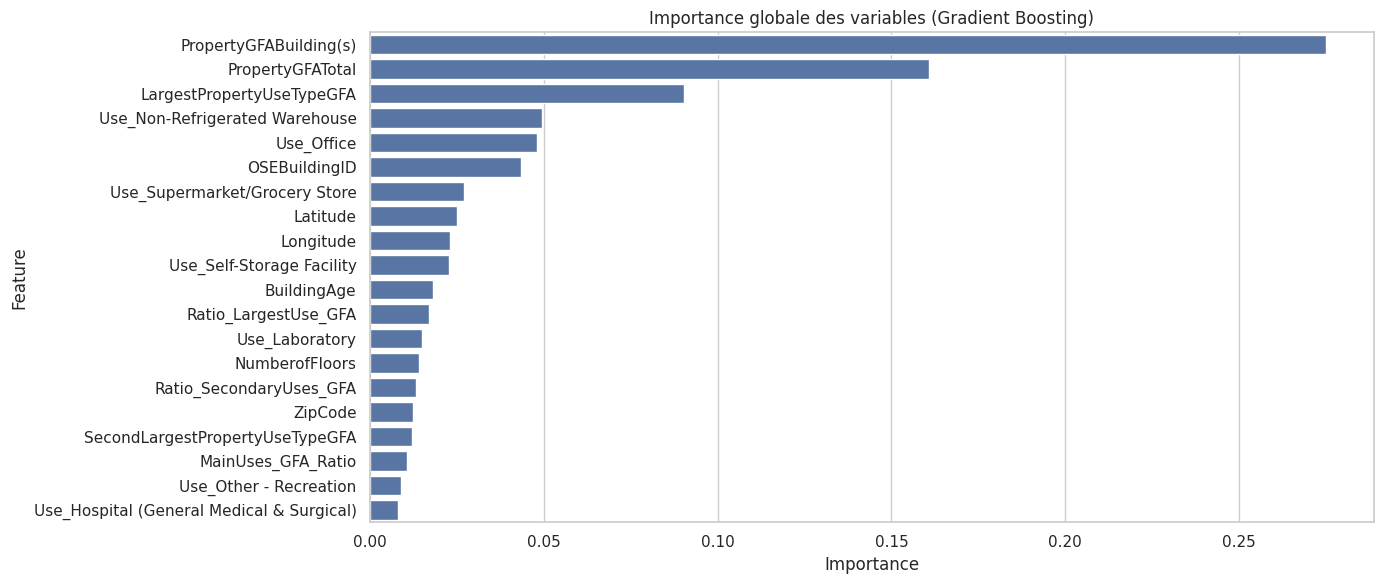

In [30]:
# Extraction des importances
importances = best_gbr.named_steps["model"].feature_importances_
feature_names = X_train.columns

# Création d'un DataFrame
fi_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

# Visualisation des 20 variables les plus importantes
plt.figure(figsize=(14,6))
sns.barplot(
    data=fi_df.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Importance globale des variables (Gradient Boosting)")
plt.tight_layout()
plt.show()

<font size="4"><b>Interprétation</b></font>

Les importances globales montrent que le modèle s'appuie avant tout sur la **taille des bâtiments**, avec une domination très nette de `PropertyGFABuilding(s)`, suivie de `PropertyGFATotal`. Ces variables constituent les **facteurs explicatifs principaux des émissions de CO<sub>2</sub>**, ce qui est cohérent d'un point de vue métier : des bâtiments plus grands nécessitent davantage d'énergie pour fonctionner, ce qui se traduit mécaniquement par des niveaux d'émissions plus élevés.

La variable `LargestPropertyUseTypeGFA` arrive ensuite, indiquant que **la surface associée à l'usage principal du bâtiment joue également un rôle déterminant**. Cela suggère que, au-delà de la taille totale, **la nature et la concentration de l'usage dominant** influencent fortement le niveau d'émissions.

Les variables de **localisation** (`Latitude`, `Longitude`, `ZipCode`) apparaissent à un niveau intermédiaire. Elles traduisent des **effets géographiques indirects**, potentiellement liés aux caractéristiques urbaines, aux infrastructures ou aux typologies de bâtiments, mais restent secondaires par rapport aux variables de surface.

Enfin, les **ratios issus du feature engineering** (`Ratio_LargestUse_GFA`, `Ratio_SecondaryUses_GFA`, `MainUses_GFA_Ratio`), ainsi que l'**âge du bâtiment** (`BuildingAge`) et des caractéristiques structurelles comme **NumberofFloors**, contribuent de manière plus modérée. Leur rôle est essentiellement **complémentaire**, permettant d'affiner les prédictions pour des bâtiments de taille comparable.

<br>

<font size="4"><b>Focus sur les usages du bâtiment</b></font>

Parmi les variables liées aux **types d'usage**, plusieurs catégories ressortent clairement, notamment `Use_Non-Refrigerated Warehouse`, `Use_Office` et `Use_Supermarket/Grocery Store`. Ces usages correspondent à des **profils d'exploitation spécifiques**, associés à des niveaux d'émissions potentiellement différents selon les équipements et les conditions d'utilisation.

D'autres usages, comme `Use_Self-Storage Facility`, `Use_Laboratory` ou `Use_Hospital`, présentent une importance plus modérée. Ils apportent une **information contextuelle utile**, permettant au modèle de distinguer des bâtiments aux caractéristiques similaires mais aux profils d'émissions différents.

> **À noter :** ces importances traduisent **la contribution des variables au modèle**, et non une relation causale directe. De plus, l'importance peut être **répartie entre variables corrélées**, en particulier lorsqu'elles décrivent différentes facettes de la surface.

<br>

<font size="4"><b>Conclusion</b></font>

Cette analyse globale confirme que le modèle repose principalement sur :
- la **taille des bâtiments**, facteur central des émissions de CO<sub>2</sub> ;
- la **répartition des surfaces selon les usages principaux** ;
- des **usages spécifiques**, complétés par des variables structurelles et des ratios issus du feature engineering.

Ces résultats sont cohérents avec les mécanismes physiques sous-jacents aux émissions, et confirment que le modèle exploite des variables pertinentes. Ils constituent une base solide pour l'**analyse locale des prédictions**, qui permettra de comprendre plus finement les facteurs expliquant les émissions à l'échelle individuelle.

## 2.3. Feature importance globale - Méthode modèle-agnostique

<font size="4"><b>Objectif</b></font>

L'objectif de cette section est de **vérifier la robustesse des importances globales** observées précédemment avec la méthode spécifique au modèle (Gradient Boosting).  
Contrairement à `feature_importances_`, la permutation importance est **indépendante du modèle** et mesure l'impact réel d'une variable sur la performance prédictive.

<br>

<font size="4"><b>Principe</b></font>

Pour chaque variable :
- on permute aléatoirement ses valeurs ;
- on mesure la dégradation de la performance du modèle ;
- plus la chute est importante, plus la variable est jugée importante.

→ Cette méthode mesure l'importance **réelle et observable** d'une variable sur les prédictions, indépendamment du fonctionnement interne du modèle.

<br>

<font size="4"><b>Calcul de la permutation importance</b></font>

In [31]:
# Calcul de la permutation importance sur le jeu de test
perm_importance = permutation_importance(
    best_gbr,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Création du DataFrame des importances
perm_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm_importance.importances_mean
    })
    .sort_values("Importance", ascending=False)
)

<font size="4"><b>Visualisation des variables les plus importantes</b></font>

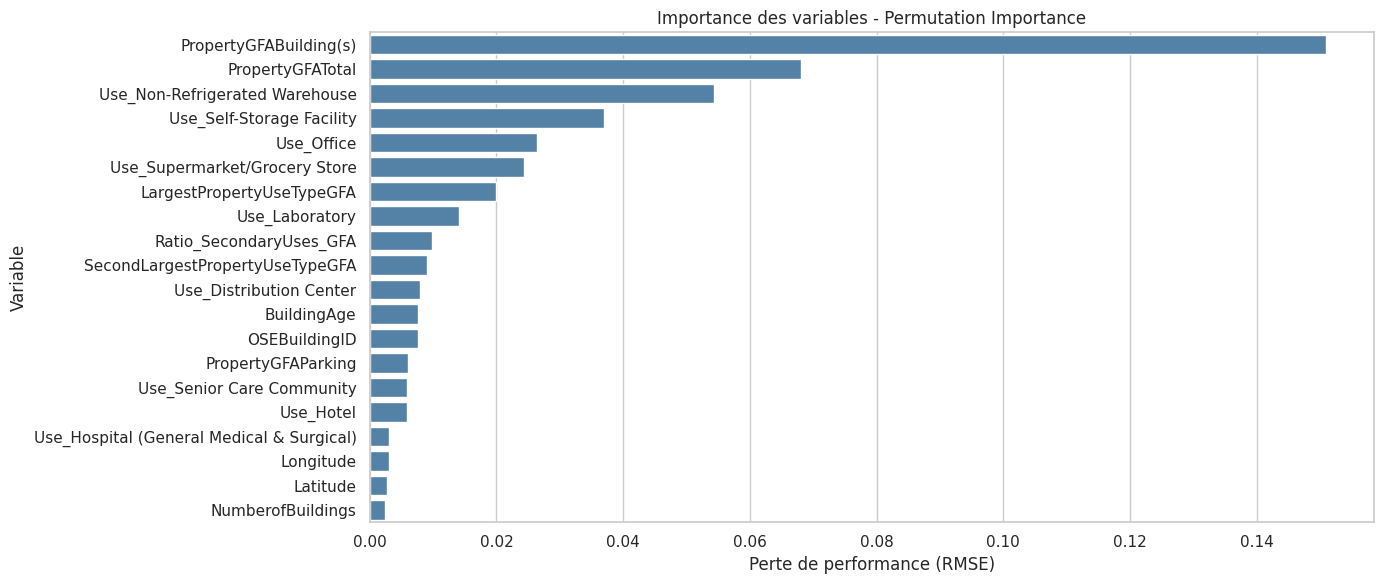

In [32]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=perm_df.head(20),
    x="Importance",
    y="Feature",
    color="steelblue"
)
plt.title("Importance des variables - Permutation Importance")
plt.xlabel("Perte de performance (RMSE)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

L'axe horizontal représente la **perte de performance du modèle** (**augmentation de la RMSE**) provoquée par la permutation d'une variable. Plus cette perte est élevée, plus la variable est essentielle aux prédictions

<br>

<font size="4"><b>Interprétation - Permutation Importance</b></font>

L'analyse par permutation confirme et **renforce les enseignements tirés de l'analyse d'importance spécifique au modèle**, tout en apportant un regard plus robuste et indépendant de l'algorithme.

- **La taille du bâtiment apparaît comme le facteur explicatif dominant des émissions de CO<sub>2</sub>** :
  - `PropertyGFABuilding(s)` est la variable la plus critique : sa permutation entraîne **la plus forte perte de performance**, indiquant une **dépendance majeure du modèle à la surface construite**.
  - `PropertyGFATotal` arrive ensuite, confirmant que **la taille globale du bâtiment constitue le principal déterminant structurel des émissions**.
- **Les usages spécifiques du bâtiment jouent également un rôle central** :
  - `Use_Non-Refrigerated Warehouse` se distingue nettement, traduisant un **profil d'émissions spécifique à ce type d'activité**.
  - D'autres usages comme `Use_Self-Storage Facility`, `Use_Office` et `Use_Supermarket/Grocery Store` figurent également parmi les variables les plus influentes, ce qui souligne que **la nature de l'activité exercée influence fortement le niveau d'émissions**, indépendamment de la surface seule.
- **Les variables décrivant la répartition des surfaces et la structure du bâtiment contribuent de manière complémentaire** :
  - `LargestPropertyUseTypeGFA` et `SecondLargestPropertyUseTypeGFA` indiquent que **la distribution des surfaces selon les usages influence les émissions**, en lien avec les besoins énergétiques spécifiques à chaque activité.
  - L'**âge du bâtiment** (`BuildingAge`) apparaît également, suggérant que **les caractéristiques techniques et les normes de construction peuvent avoir un impact sur le niveau d'émissions**.
- **Les ratios et variables contextuelles ont une influence plus limitée** :
  - `Ratio_SecondaryUses_GFA` ou `PropertyGFAParking` apportent une information complémentaire, mais leur impact reste secondaire.
  - Les variables géographiques (`Longitude`, `Latitude`) et structurelles (`NumberofBuildings`) présentent une contribution plus faible, traduisant un rôle essentiellement contextuel.

<br>

<font size="4"><b>Conclusion - Apport de la permutation importance</b></font>

Cette analyse modèle-agnostique **confirme clairement la hiérarchie des facteurs expliquant les émissions de CO<sub>2</sub>** :
- Les émissions sont principalement déterminées par :
  - **la surface des bâtiments**,
  - **le type d'usage et certaines activités spécifiques**,
  - **la répartition interne des surfaces**.
- Les variables structurelles complémentaires et les caractéristiques contextuelles permettent d'affiner les prédictions, mais restent **secondaires face aux caractéristiques physiques et fonctionnelles des bâtiments**.

La forte cohérence entre l'importance spécifique au Gradient Boosting et la permutation importance **renforce la confiance dans le modèle final**. Elle confirme que le modèle s'appuie sur des variables pertinentes et identifie clairement les principaux facteurs expliquant les émissions de CO<sub>2</sub>, ce qui constitue une base solide pour l'analyse locale des prédictions.

## 2.4. Limites de l'analyse globale et transition vers l'analyse locale

Les analyses d'importance globale précédentes permettent d'identifier **les variables qui influencent le plus les prédictions en moyenne sur l'ensemble du jeu de données**. Elles offrent une vision synthétique et utile du fonctionnement général du modèle.

Cependant, **ces approches présentent des limites importantes** :
- Une variable faiblement importante au niveau global peut être **déterminante pour certains bâtiments spécifiques**.
- Les prédictions individuelles peuvent reposer sur des **combinaisons particulières de caractéristiques**, parfois rares ou atypiques, qui ne sont pas visibles dans une analyse agrégée.
- L'importance globale ne permet pas d'expliquer **pourquoi une prédiction précise est élevée ou faible pour un bâtiment donné**.

Ainsi, pour comprendre finement le raisonnement du modèle et renforcer sa transparence, il est nécessaire de compléter cette approche par **une analyse locale des prédictions**.

> → La section suivante se concentre donc sur l'explication **individuelle** des décisions du modèle, afin d'identifier, pour des bâtiments précis, les variables qui ont le plus contribué aux prédictions.

## 2.5. Feature importance locale et globale - SHAP

<font size="4"><b>Objectif</b></font>

Après l'analyse globale de l'importance des variables, cette section vise à **expliquer finement les prédictions du modèle**, à la fois :
- **au niveau global**, en observant comment chaque variable influence les prédictions sur l'ensemble du jeu de données ;
- **au niveau local**, en expliquant la prédiction pour des bâtiments précis.

Cette approche permet de renforcer la **transparence du modèle** et de mieux relier ses décisions à des logiques métier compréhensibles.

### 2.5.1. Pourquoi utiliser SHAP ?

SHAP (SHapley Additive exPlanations) s'appuie sur la théorie des jeux pour attribuer à chaque variable une contribution équitable à la prédiction du modèle, ce qui permet une interprétation fiable à la fois globale et locale.

Elle repose sur les principes suivants :
- chaque variable contribue à la prédiction finale ;
- la prédiction est expliquée comme la somme d'une valeur moyenne (baseline) et des contributions individuelles des variables ;
- les contributions sont calculées de manière équitable (valeurs de Shapley).

Avantages de SHAP dans ce projet :
- méthode **model-agnostic** (compatible avec Gradient Boosting) ;
- interprétation **locale et globale** cohérente ;
- résultats stables et largement recommandés en XAI ;
- très adaptée aux modèles non linéaires.

### 2.5.2. Analyse SHAP globale

**Objectif :** Identifier les variables qui influencent le plus les prédictions **sur l'ensemble des bâtiments**, et comprendre **le sens de leur impact** (augmentation ou diminution de la consommation prédite).

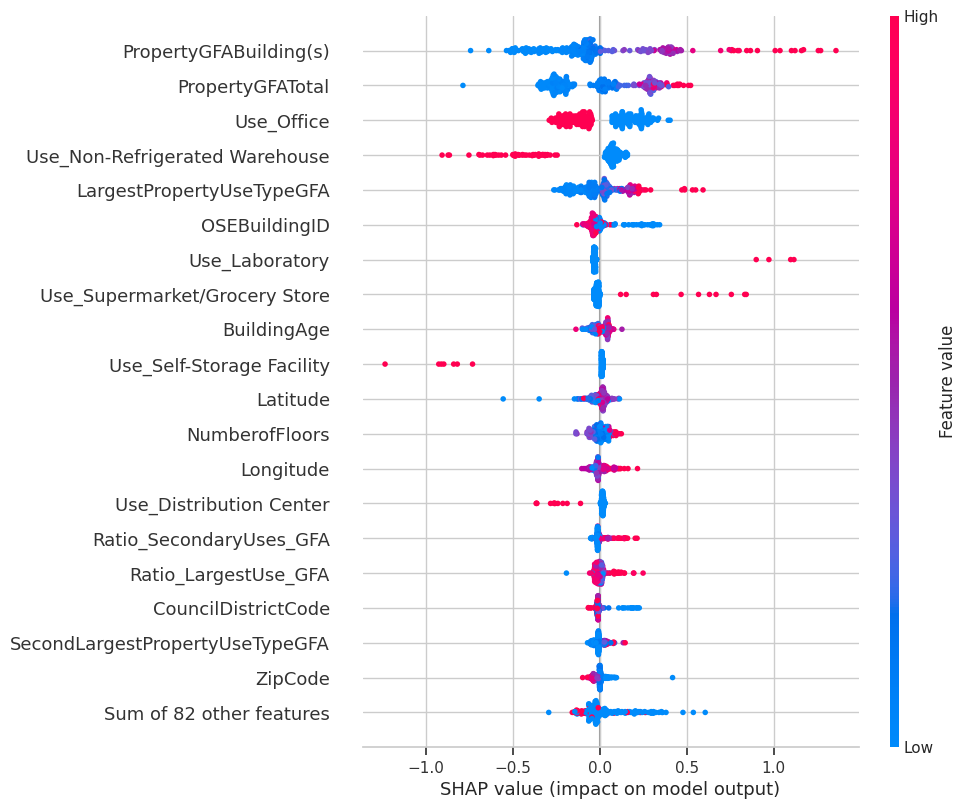

In [33]:
# Récupération des étapes du pipeline
imputer = best_gbr.named_steps["imputer"]
gbr_model = best_gbr.named_steps["model"]

# Imputation
X_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Explainer arbre (le plus stable pour GradientBoostingRegressor)
explainer = shap.TreeExplainer(gbr_model, data=X_imp)

# Calcul SHAP (désactive le check additivity)
shap_exp = explainer(X_imp, check_additivity=False)

# Graphique global
shap.plots.beeswarm(shap_exp, max_display=20)

<font size="4"><b>Interprétation du diagramme beeswarm SHAP</b></font>

Le diagramme beeswarm SHAP permet d'analyser simultanément l'importance globale des variables, le sens de leur influence sur la prédiction des émissions de CO<sub>2</sub> et la variabilité de cet effet selon les bâtiments.

<br>

1. **Variables dominantes**

Les variables liées aux **surfaces** apparaissent clairement comme les plus influentes :
- `PropertyGFABuilding(s)`
- `PropertyGFATotal`
- `LargestPropertyUseTypeGFA`

Pour ces variables, les **valeurs élevées (points rouges)** sont majoritairement situées **à droite**, ce qui signifie qu'elles **augmentent les émissions de CO<sub>2</sub> prédites**, tandis que les **valeurs faibles (points bleus)** contribuent à les réduire.

→ Ce résultat est **cohérent d'un point de vue métier** : des bâtiments plus grands nécessitent davantage d'énergie pour fonctionner, ce qui se traduit mécaniquement par des **émissions de CO<sub>2</sub> plus importantes**.

La **dispersion des valeurs SHAP** pour ces variables indique également la présence **d'effets non linéaires** et d'**interactions avec d'autres caractéristiques**, notamment le type d'usage.

<br>

2. **Effet des usages spécifiques (`Use_*`)**

Les variables liées aux **types d'usage** jouent un rôle structurant et différenciant :
- `Use_Office` montre un **effet globalement négatif**, indiquant que les bâtiments de bureaux sont associés à des **émissions de CO<sub>2</sub> plus faibles**, probablement en raison de profils d'usage plus modérés et d'équipements énergétiques généralement moins énergivores que dans des activités industrielles ou spécialisées.
- `Use_Supermarket/Grocery Store` et `Use_Laboratory` présentent eux des **impacts positifs marqués pour certains bâtiments**, reflétant des **activités plus énergivores**.
- À l'inverse, `Use_Non-Refrigerated Warehouse` ou `Use_Self-Storage Facility` montrent fréquemment des **effets négatifs**, traduisant des **profils d'émissions plus faibles**, cohérents avec des usages nécessitant moins d'équipements énergétiques.

→ Ces résultats montrent que le **type d'activité influence fortement les émissions**, au-delà de la seule taille du bâtiment.

<br>

3. **Rôle des ratios et variables structurelles secondaires**

Les variables issues du feature engineering, telles que :
- `Ratio_LargestUse_GFA`
- `Ratio_SecondaryUses_GFA`

présentent :
- une **importance globale plus modérée**,
- mais une **dispersion visible autour de zéro**.

Elles jouent donc un **rôle d'ajustement**, en modulant les émissions selon la **répartition des usages internes**, plutôt qu'en déterminant directement leur niveau.

L'**âge du bâtiment** (`BuildingAge`) intervient également comme facteur secondaire, suggérant que **les caractéristiques techniques et l'efficacité énergétique influencent les émissions**.

<br>

4. **Variables de localisation et d'identification**

Les variables géographiques (`Latitude`, `Longitude`, `ZipCode`, `CouncilDistrictCode`) ont un **impact limité mais réel**, traduisant des **effets contextuels secondaires**, liés notamment aux caractéristiques urbaines ou aux types de bâtiments présents dans certaines zones.

La variable `OSEBuildingID`, bien que présente, ne reflète pas une relation causale directe, mais probablement des **similarités structurelles entre certains groupes de bâtiments**.

<br>

5. **Lecture globale du modèle**

Dans son ensemble, ce beeswarm montre que le modèle :
- repose principalement sur **des caractéristiques structurelles fondamentales**, en particulier la surface des bâtiments ;
- intègre efficacement l'**influence spécifique des usages**, qui modulent fortement les émissions ;
- exploite des **interactions complexes et non linéaires** entre les différentes variables ;
- produit des prédictions **cohérentes et interprétables d'un point de vue métier**.

Cette analyse SHAP globale confirme que les **émissions de CO<sub>2</sub> sont principalement déterminées par la taille et la fonction des bâtiments**, tout en étant modulées par leurs caractéristiques structurelles et fonctionnelles.

Elle constitue une base solide pour l'**analyse locale des prédictions**, afin de comprendre précisément les facteurs expliquant les émissions pour des bâtiments individuels.

### 2.5.3. Analyse SHAP locale (explication individuelle)

**Objectif :** Expliquer **pourquoi le modèle prédit une émission donnée pour un bâtiment précis**.

Trois types de bâtiments peuvent être analysés :
- un bâtiment à **forte émission prédite** ;
- un bâtiment à **faible émission prédite** ;
- un cas **atypique** ou intermédiaire.

#### 2.5.3.1. Sélection automatique des 3 cas

**Règles :**

- **forte émission prédite** = plus grande prédiction
- **faible émission prédite** = plus petite prédiction
- **atypique** = forte erreur absolue

In [34]:
# Sélection des cas à analyser

# Cas 1 : forte émission prédite
idx_high = y_pred_real.idxmax()

# Cas 2 : faible émission prédite
idx_low = y_pred_real.idxmin()

# Cas 3 : cas atypique = plus grande erreur absolue (en valeur réelle)
abs_err_real = (y_test_real - y_pred_real).abs()
idx_weird = abs_err_real.idxmax()
weird_label = "cas atypique (plus grande erreur)"

idx_high, idx_low, idx_weird

(np.int64(532), np.int64(573), np.int64(270))

#### 2.5.3.2. Plots SHAP locaux (waterfall) pour les 3 cas

In [35]:
def plot_local_shap(idx, title, max_display=10):
    i = X_imp.index.get_loc(idx)  # position dans X_imp

    pred_real = y_pred_real.loc[idx]
    test_real = y_test_real.loc[idx]
    err_real = abs(test_real - pred_real)

    print(
        f"{title} — index={idx} | "
        f"prédiction={pred_real:,.0f} | "
        f"vrai={test_real:,.0f} | "
        f"erreur_abs={err_real:,.0f}"
    )

    shap.plots.waterfall(shap_exp[i], max_display=max_display)

<font size="4"><b>Bâtiment à forte émission prédite</b></font>

Bâtiment à forte émission prédite — index=532 | prédiction=1,099 | vrai=190 | erreur_abs=909


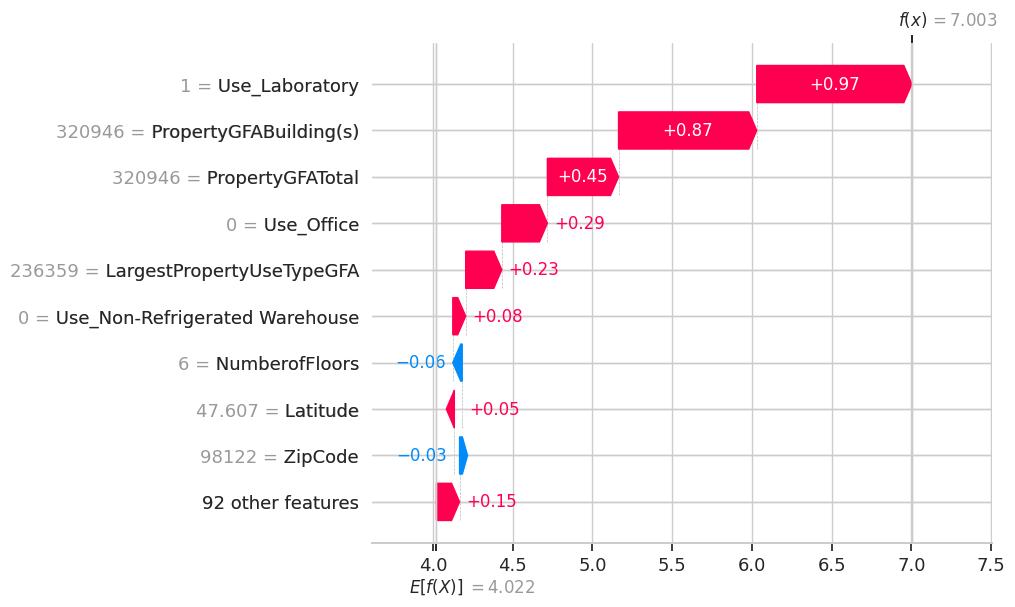

In [36]:
# 1) forte émission prédite
plot_local_shap(idx_high, "Bâtiment à forte émission prédite")

Ce diagramme *waterfall* montre comment le modèle construit une **prédiction très élevée de consommation énergétique** pour ce bâtiment, en partant d'une valeur moyenne de référence et en ajoutant successivement les contributions des variables les plus influentes.

<br>

1. **Surfaces : facteur structurel majeur des émissions**

La prédiction élevée des émissions de CO<sub>2</sub> est fortement expliquée par les **caractéristiques de surface du bâtiment**, qui apportent des contributions positives importantes :
- La **surface bâtie** (`PropertyGFABuilding(s)`) constitue l'un des facteurs les plus déterminants, contribuant fortement à l'augmentation de la prédiction.
- La **surface totale** (`PropertyGFATotal`) renforce également significativement cet effet.
- La **surface associée à l'usage principal** (`LargestPropertyUseTypeGFA`) amplifie encore cette tendance.

Ces contributions indiquent que **la taille globale du bâtiment est un déterminant central des émissions de CO<sub>2</sub>**, ce qui est cohérent avec le fait que des bâtiments plus grands nécessitent davantage d'énergie pour leur fonctionnement, entraînant mécaniquement des émissions plus élevées.

<br>

2. **Effet déterminant de l'usage laboratoire**

La présence de l'usage `Use_Laboratory` constitue le facteur individuel le plus influent dans ce cas, avec une contribution très fortement positive à la prédiction.

Cela indique que **les laboratoires sont associés à des niveaux d'émissions particulièrement élevés**, probablement en raison de :
- la présence d'équipements énergivores,
- des besoins importants en ventilation et renouvellement d'air,
- et des exigences techniques spécifiques liées aux activités scientifiques.

Ce type d'usage agit donc comme un **facteur amplificateur majeur des émissions**, indépendamment de la surface seule.

<br>

3. **Contributions secondaires et effets modérateurs**

Les autres variables jouent un rôle plus limité mais contribuent à ajuster la prédiction :
- L'**absence d'un usage de type bureau** (`Use_Office = 0`) contribue positivement à la prédiction, ce qui est cohérent avec le fait que les bureaux sont généralement associés à des émissions plus faibles que des usages techniques spécialisés.
- Le **nombre d'étages** (`NumberofFloors`) exerce un léger effet négatif, suggérant que la structure verticale du bâtiment atténue marginalement la prédiction dans ce cas précis.
- Les variables de **localisation** (`Latitude`, `ZipCode`) ont un impact faible, indiquant un rôle essentiellement contextuel.

Les nombreuses autres variables ont un effet cumulé limité, confirmant que la prédiction repose principalement sur quelques facteurs dominants.

<br>

4. **Lecture globale et cohérence du raisonnement du modèle**

Dans ce cas, le modèle prédit un niveau élevé d'émissions de CO<sub>2</sub>, principalement en raison de la **combinaison de deux facteurs majeurs** :
- une **surface importante**,
- et surtout la **présence d'un usage laboratoire**, fortement émetteur.

Le raisonnement du modèle apparaît **cohérent et conforme aux connaissances métier**, les laboratoires étant connus pour leur intensité énergétique élevée et leurs émissions associées.

Cette analyse confirme que le modèle identifie correctement les **profils de bâtiments à fortes émissions**, en s'appuyant sur des caractéristiques structurelles et fonctionnelles pertinentes.

<font size="4"><b>Bâtiment à faible émission prédite</b></font>

Bâtiment à faible émission prédite — index=573 | prédiction=6 | vrai=14 | erreur_abs=8


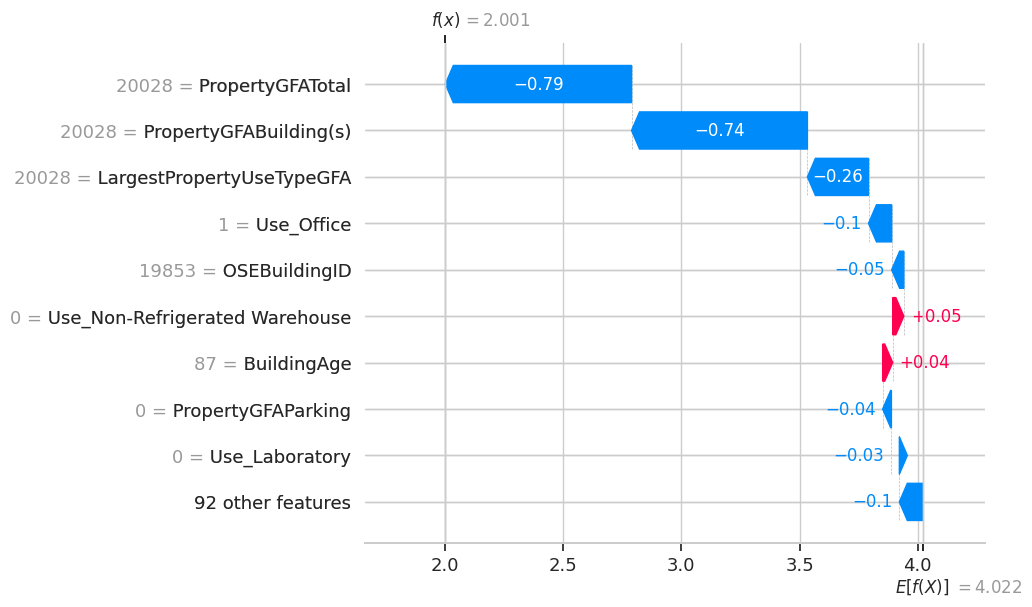

In [37]:
# 2) faible émission prédite
plot_local_shap(idx_low, "Bâtiment à faible émission prédite")

Ce diagramme *waterfall* illustre les facteurs qui conduisent le modèle à prédire une **consommation énergétique très inférieure à la moyenne**, en partant de la valeur de référence globale et en appliquant successivement les contributions des variables propres à ce bâtiment.

<br>

1. **Faible surface : déterminant principal des faibles émissions**

La **petite taille du bâtiment** constitue le facteur explicatif dominant de la faible prédiction des émissions de CO<sub>2</sub> :
- La **surface totale** (`PropertyGFATotal`) apporte la contribution négative la plus importante, réduisant fortement la prédiction.
- La **surface bâtie** (`PropertyGFABuilding(s)`) renforce cet effet dans des proportions similaires.
- La **surface associée à l'usage principal** (`LargestPropertyUseTypeGFA`), également faible, contribue à diminuer davantage la prédiction.

Ces résultats indiquent que le modèle associe clairement **faible surface et faibles émissions de CO<sub>2</sub>**, ce qui est cohérent puisque des bâtiments plus petits nécessitent moins d'énergie et génèrent donc moins d'émissions.

<br>

2. **Effet modérateur de l'usage bureau**

La présence de l'usage `Use_Office` contribue également à **réduire la prédiction des émissions**.

Cela suggère que les **bâtiments de bureaux sont associés à des profils d'émissions plus faibles**, probablement en raison :
- d'une intensité énergétique modérée,
- d'équipements moins énergivores que des usages techniques ou industriels,
- et d'un fonctionnement généralement plus standardisé.

Cet usage agit donc comme un **facteur structurel de modération des émissions** dans ce cas précis.

<br>

3. **Contributions secondaires et ajustements**

Les autres variables jouent un rôle plus marginal dans la prédiction :
- L'**absence d'un usage laboratoire** (`Use_Laboratory = 0`) contribue à diminuer la prédiction, ce qui est cohérent avec le caractère fortement émetteur de ce type d'activité.
- L'**absence de surface de parking** (`PropertyGFAParking = 0`) exerce également un effet légèrement négatif.
- À l'inverse, certaines caractéristiques comme l'**âge du bâtiment** (`BuildingAge`) contribuent légèrement à augmenter la prédiction, possiblement en raison d'une efficacité énergétique moindre.

Ces contributions restent toutefois secondaires face à l'impact dominant de la surface.

<br>

4. **Lecture globale et cohérence du raisonnement du modèle**

La faible prédiction des émissions de CO<sub>2</sub> résulte principalement d'une **combinaison cohérente de facteurs structurels favorables** :
- une **surface globale réduite**,
- un **usage de type bureau**, associé à des émissions modérées,
- et l'**absence d'activités fortement émettrices**.

L'erreur absolue observée reste **relativement limitée en valeur absolue**, ce qui indique que le modèle parvient à **correctement identifier les bâtiments à faibles émissions**.

Ce cas illustre un **profil typique de bâtiment peu émetteur**, pour lequel le raisonnement du modèle apparaît **stable, logique et aligné avec les connaissances métier**.

<font size="4"><b>Cas atypique (plus grande erreur)</b></font>

Bâtiment cas atypique (plus grande erreur) — index=270 | prédiction=842 | vrai=3,995 | erreur_abs=3,153


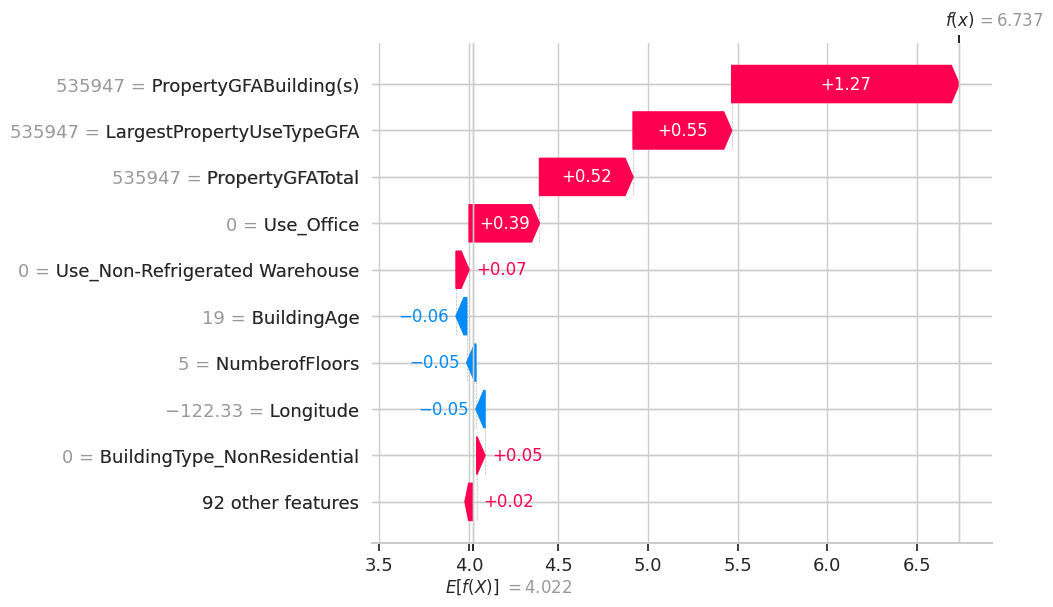

In [38]:
# 3) atypique / intermédiaire
plot_local_shap(idx_weird, f"Bâtiment {weird_label}")

Ce diagramme *waterfall* met en évidence un cas pour lequel la **prédiction du modèle est très éloignée de la valeur réelle**, malgré un raisonnement interne qui reste cohérent au regard des variables disponibles.

<br>

1. **Un profil structurel associé à de fortes émissions potentielles**

Comme pour le bâtiment à forte émission prédite, le modèle s'appuie principalement sur des **variables de surface très élevées**, qui expliquent l'essentiel de la prédiction :
- La **surface bâtie** (`PropertyGFABuilding(s)`) constitue la contribution positive la plus importante, augmentant fortement la prédiction.
- La **surface associée à l'usage principal** (`LargestPropertyUseTypeGFA`) et la **surface totale** (`PropertyGFATotal`) renforcent ce signal dans des proportions similaires.

Ces contributions indiquent que le modèle associe ce bâtiment à un **profil de grande taille fortement émetteur**, ce qui est cohérent puisque des surfaces importantes impliquent généralement des besoins énergétiques plus élevés et donc davantage d'émissions de CO<sub>2</sub>.

<br>

2. **Effets complémentaires liés à l'usage et aux caractéristiques structurelles**

Certaines variables viennent amplifier ou modérer cette tendance :
- L'**absence de l'usage bureau** (`Use_Office = 0`) contribue à augmenter la prédiction, ce qui suggère que d'autres types d'activités sont associés à des émissions plus élevées.
- L'**absence d'usage entrepôt** (`Use_Non-Refrigerated Warehouse = 0`) exerce également un effet positif modéré.
- À l'inverse, des variables comme le **nombre d'étages**, la **localisation** (`Longitude`) et l'**âge du bâtiment** (`BuildingAge`) apportent de légères contributions négatives, atténuant marginalement la prédiction sans inverser la tendance globale.

Ces effets restent toutefois secondaires face à l'impact dominant des surfaces.

<br>

3. **Origine probable de l'erreur importante**

Malgré un raisonnement cohérent, la **valeur réelle des émissions de CO<sub>2</sub> est très largement supérieure à la prédiction**, ce qui révèle une **sous-estimation importante du modèle**.

Cette situation suggère que :
- certaines **caractéristiques fortement émettrices ne sont pas capturées dans les variables disponibles**, comme :
  - l'intensité réelle d'exploitation,
  - la nature précise des équipements,
  - ou des activités particulièrement énergivores ;

- le bâtiment présente probablement un **profil atypique**, dont les émissions sont **exceptionnellement élevées au regard de ses seules caractéristiques structurelles** ;

la relation entre surface et émissions est ici **plus complexe que celle apprise globalement par le modèle**.

<br>

4. **Enseignements méthodologiques**

Ce cas illustre une limite classique des modèles prédictifs globaux :
- le modèle **raisonne de manière logique à partir des informations disponibles** ;
- mais il peut **sous-estimer des situations extrêmes**, lorsque celles-ci dépendent de facteurs non observés.

L'erreur importante ne traduit donc pas un dysfonctionnement du modèle, mais plutôt la présence de **bâtiments atypiques difficilement prévisibles à partir des seules variables structurelles et d'usage standardisées**.

<br>

5. **Conclusion locale**

Ce cas atypique confirme que :
- les **variables de surface dominent fortement la prédiction des émissions de CO<sub>2</sub>** ;
- mais certains bâtiments peuvent présenter des **niveaux d'émissions exceptionnellement élevés**, difficiles à anticiper sans informations plus détaillées.

Il souligne l'importance de l'**analyse SHAP locale**, qui permet d'identifier les situations où les prédictions doivent être **interprétées avec prudence**, en particulier dans une perspective opérationnelle ou d'aide à la décision.

## 2.6. Limites et précautions d'interprétation

Les analyses d'importance globale et locale menées à l'aide de SHAP apportent une **transparence essentielle** sur le fonctionnement du modèle final. Toutefois, ces résultats doivent être interprétés avec **prudence**, en tenant compte de plusieurs limites inhérentes à l'approche.

<br>

1. **SHAP décrit le raisonnement du modèle, pas une relation causale**

Les valeurs SHAP indiquent **comment le modèle utilise les variables pour produire une prédiction**, mais elles ne traduisent **en aucun cas une relation de causalité réelle** entre une caractéristique et la consommation énergétique.

Ainsi :
- une variable fortement contributive n'est pas nécessairement un levier d'action direct ;
- certaines importances peuvent refléter des **corrélations indirectes** ou des effets de structure présents dans les données.

→ Cette distinction est essentielle pour éviter toute **sur-interprétation métier** des résultats.

<br>

2. **Forte dépendance à la qualité et à la représentativité des features**

Les explications fournies par SHAP sont **strictement conditionnées par les variables disponibles** dans le jeu de données :
> si une caractéristique déterminante n'est pas mesurée (intensité d'usage réel, équipements spécifiques, horaires d'exploitation, etc.), le modèle ne peut ni l'exploiter, ni l'expliquer.

Cela est particulièrement visible dans les **cas atypiques**, où le modèle raisonne de manière cohérente mais reste incapable d'anticiper des consommations extrêmes non décrites par les features.

<br>

3. **Sensibilité aux transformations et à la complexité des variables**

L'interprétation des valeurs SHAP dépend également des **transformations appliquées aux données** :
- l'utilisation d'une cible transformée (`log1p`) modifie l'échelle d'interprétation des contributions ;
- des variables agrégées ou abstraites (ratios, encodages catégoriels) rendent parfois l'analyse moins intuitive.

Il est donc important de :
- toujours replacer les contributions SHAP dans leur **contexte de modélisation** ;
- éviter les conclusions hâtives sur l'impact réel d'une variable sans analyse complémentaire.

<br>

4. **Importance globale vs importance locale**

Enfin, il convient de rappeler qu'une variable :
- peut être **peu importante globalement**,
- tout en étant **déterminante localement** pour certains bâtiments spécifiques.

Les analyses globale et locale sont donc **complémentaires** :
- la première permet de comprendre la logique générale du modèle ;
- la seconde éclaire des décisions individuelles, parfois atypiques.

<br>

<font size="4"><b>Conclusion</b></font>

Cette section met en évidence que les outils d'explicabilité comme SHAP sont **indispensables pour comprendre et justifier un modèle**, mais qu'ils doivent être utilisés avec **discernement**.

Ils constituent un **outil d'aide à l'interprétation**, et non une preuve causale, et doivent toujours être croisés avec :
- la connaissance métier,
- la qualité des données,
- et les limites structurelles du modèle.

Cette prise de recul est essentielle pour garantir une **utilisation responsable et pertinente** des modèles prédictifs dans un contexte réel.

## 2.7. Conclusion de l'étape 2

Cette étape a permis d'apporter une **lecture claire et approfondie du modèle final**, tant à l'échelle globale qu'à l'échelle individuelle.

Les analyses d'importance globale (spécifique au modèle et modèle-agnostique) montrent que la **consommation énergétique est principalement expliquée par des caractéristiques structurelles**, en particulier :
- la surface totale et la surface bâtie,
- la répartition des usages principaux,
- certains usages spécifiques à forte intensité énergétique.

Les analyses SHAP locales confirment cette hiérarchie tout en mettant en évidence la **variabilité des mécanismes explicatifs selon les bâtiments**, notamment dans les cas d'émissions très élevées, très faibles ou atypiques. Le modèle adopte ainsi un raisonnement cohérent, combinant taille, structure et usage pour ajuster ses prédictions.

La cohérence observée entre :
- les performances globales du modèle,
- les importances de variables,
- et les explications locales,

renforce la **fiabilité et la crédibilité du modèle**, qui devient désormais **interprétable et justifiable auprès de parties prenantes non techniques**.

Cette étape marque une transition naturelle vers la suite du projet, qui se concentrera sur l'**analyse de l'influence de l'`ENERGYSTARScore`**, variable jusqu'ici mise de côté. L'objectif sera d'**évaluer son apport réel au modèle**, tant en termes de performance que d'interprétabilité, afin de déterminer s'il constitue un levier pertinent pour améliorer la prédiction des émissions de CO<sub>2</sub>.

# 3. Analyse de l'influence de l'EnergyStarScore

Jusqu'à présent, la variable `ENERGYSTARScore` a volontairement été **mise de côté** lors des phases de modélisation. Ce choix était motivé par sa nature particulière : il s'agit d'un **score synthétique**, potentiellement construit à partir d'informations proches des émissions de CO<sub>2</sub> elles-mêmes, ce qui pouvait introduire un **risque de fuite d'information (data leakage)**.

À ce stade du projet, le modèle final (Gradient Boosting optimisé) étant stabilisé et interprété, il devient pertinent de tester explicitement l'impact de cette variable.

L'objectif de cette section est donc de :
- mesurer l'influence réelle de `ENERGYSTARScore` sur les performances du modèle ;
- comparer les résultats **avec et sans cette variable**, dans un cadre expérimental strictement identique ;
- déterminer si son intégration améliore réellement la capacité prédictive du modèle, ou si son apport reste marginal au regard des risques méthodologiques.

Cette analyse permettra de conclure de manière argumentée sur la pertinence de conserver ou non `ENERGYSTARScore` dans une version opérationnelle du modèle.

## 3.1. Construction du sous-ensemble avec `ENERGYSTARScore`

Afin d'évaluer proprement l'impact de `ENERGYSTARScore`, il est nécessaire de :
- Ne conserver que les individus déjà utilisés dans `X_train` et `X_test`
- Éliminer les observations pour lesquelles `ENERGYSTARScore` est manquant
- Garantir l'alignement via `OSEBuildingID`

Cela permet :
- d'éviter toute fuite d'information,
- de comparer strictement les performances avec et sans la variable,
- de conserver la cohérence des splits train/test.


In [39]:
# 1) Mapping OSEBuildingID -> ENERGYSTARScore depuis df initial
energy_map = df.set_index("OSEBuildingID")["ENERGYSTARScore"]

# 2) Ajout du score
X_train_es = X_train.copy()
X_test_es  = X_test.copy()

X_train_es["ENERGYSTARScore"] = X_train_es["OSEBuildingID"].map(energy_map)
X_test_es["ENERGYSTARScore"]  = X_test_es["OSEBuildingID"].map(energy_map)

# 3) Filtrage : uniquement les observations où le score est présent
mask_train = X_train_es["ENERGYSTARScore"].notna()
mask_test  = X_test_es["ENERGYSTARScore"].notna()

X_train_es = X_train_es.loc[mask_train]
X_test_es  = X_test_es.loc[mask_test]

# 4) Alignement y
y_train_es = y_train.loc[X_train_es.index]
y_test_es  = y_test.loc[X_test_es.index]

print("Train subset:", X_train_es.shape, " | y:", y_train_es.shape)
print("Test subset:", X_test_es.shape, " | y:", y_test_es.shape)

Train subset: (737, 102)  | y: (737,)
Test subset: (188, 102)  | y: (188,)


## 3.2. Comparaison du modèle avec et sans ENERGYSTARScore

**Objectif -** Mesurer rigoureusement l'impact de ENERGYSTARScore sur :
- la capacité explicative du modèle (R²),
- l'erreur moyenne (MAE),
- l'erreur globale (RMSE).

La comparaison est réalisée :
- sur **le même sous-ensemble d'individus**,
- avec **la même validation croisée**,
- et **le même modèle optimisé (Gradient Boosting)**.

Cela garantit une comparaison équitable.

### 3.2.1. Modèle sans ENERGYSTARScore

In [40]:
X_train_no_es = X_train_es.drop(columns=["ENERGYSTARScore"], errors="ignore")

cv_no_es = cross_validate(
    best_gbr,
    X_train_no_es,
    y_train_es,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

results_no_es = {
    "Model": "Gradient Boosting (sans EnergyStarScore)",
    "R2_CV": np.mean(cv_no_es["test_r2"]),
    "MAE_CV": -np.mean(cv_no_es["test_mae"]),
    "RMSE_CV": np.sqrt(-np.mean(cv_no_es["test_mse"]))
}

### 3.2.2. Modèle avec ENERGYSTARScore

In [41]:
cv_with_es = cross_validate(
    best_gbr,
    X_train_es,
    y_train_es,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

results_with_es = {
    "Model": "Gradient Boosting (avec EnergyStarScore)",
    "R2_CV": np.mean(cv_with_es["test_r2"]),
    "MAE_CV": -np.mean(cv_with_es["test_mae"]),
    "RMSE_CV": np.sqrt(-np.mean(cv_with_es["test_mse"]))
}

### 3.2.3. Comparaison des scores

In [42]:
comparison_es = pd.DataFrame([results_no_es, results_with_es])
comparison_es

,Model,R2_CV,MAE_CV,RMSE_CV
0,Gradient Boosting (sans EnergyStarScore),0.58,0.71,0.91
1,Gradient Boosting (avec EnergyStarScore),0.63,0.68,0.85


L'ajout de la variable **ENERGYSTARScore** améliore significativement les performances du modèle de prédiction des émissions de CO<sub>2</sub>.

<br>

<font size="4"><b>Comparaison des performances</b></font>

- **Sans ENERGYSTARScore**
  - R² ≈ 0.58
  - MAE ≈ 0.71
  - RMSE ≈ 0.91

- **Avec ENERGYSTARScore**
  - R² ≈ 0.63
  - MAE ≈ 0.68
  - RMSE ≈ 0.85

L'amélioration est cohérente sur l'ensemble des métriques :
- Le **R² augmente** (+0.05), indiquant que le modèle explique une part plus importante de la variance des émissions de CO<sub>2</sub>.
- Le **MAE diminue**, ce qui signifie que les prédictions sont globalement plus proches des émissions réelles.
- Le **RMSE baisse également**, traduisant une meilleure maîtrise des erreurs, notamment sur les bâtiments les plus émetteurs.

<br>

<font size="4"><b>Interprétation métier</b></font>

Cette amélioration montre que **l'ENERGYSTARScore contient une information pertinente sur le niveau d'émissions de CO<sub>2</sub> des bâtiments**.

En effet, ce score reflète indirectement :
- l'**efficacité énergétique globale** du bâtiment,
- son **niveau de performance par rapport à des bâtiments similaires**,
- et donc, en partie, son **niveau d'émissions de gaz à effet de serre**, puisque les émissions de CO<sub>2</sub> sont étroitement liées à la consommation énergétique et aux sources d'énergie utilisées.

Ainsi, ce score agit comme un **indicateur synthétique de performance environnementale**, utile pour améliorer la précision des prédictions.

<br>

<font size="4"><b>Point de vigilance - Risque de fuite d'information</b></font>

Il est néanmoins important de considérer la nature de cette variable :

> Si l'`ENERGYSTARScore` est calculé à partir de données directement liées à la consommation énergétique ou aux émissions réelles, son utilisation peut introduire un **risque de data leakage partiel**, ou réduire l'intérêt du modèle dans un contexte où ce score ne serait pas disponible.

Son utilisation doit donc être évaluée selon le **contexte opérationnel** :
- pertinente si le score est **disponible au moment de la prédiction** ;
- moins adaptée si l'objectif est de **prédire les émissions de CO<sub>2</sub> pour des bâtiments ne disposant pas encore de ce score**.

<br>

<font size="4"><b>Conclusion</b></font>

L'`ENERGYSTARScore` constitue une **variable fortement prédictive des émissions de CO<sub>2</sub>**.

Son intégration permet une **amélioration claire et cohérente des performances du modèle**, confirmant sa pertinence pour la prédiction.

Cependant, son utilisation doit être **justifiée au regard du contexte métier**, afin de garantir la validité opérationnelle du modèle et d'éviter toute dépendance excessive à un indicateur déjà fortement lié à la performance énergétique et environnementale du bâtiment.

# 4. Conclusion générale du notebook

Ce notebook avait pour objectif de construire un modèle prédictif robuste des **émissions totales de CO<sub>2</sub> des bâtiments non résidentiels**, en suivant une démarche complète et rigoureuse :
- préparation et structuration des données,
- feature engineering adapté à la problématique,
- comparaison de plusieurs familles de modèles,
- optimisation des hyperparamètres,
- analyse d'interprétabilité globale et locale,
- étude de l'impact d'une variable métier clé : **ENERGYSTARScore**.

Ce travail s'inscrit dans la continuité du notebook précédent, consacré à la **prédiction de la consommation énergétique**, permettant ainsi de comparer la capacité des modèles à prédire deux indicateurs étroitement liés mais distincts de la performance environnementale des bâtiments.

<br>

<font size="4"><b>1. Performance du modèle retenu</b></font>

Après comparaison entre modèles linéaires et modèles d'ensemble :
- Le **Gradient Boosting** s'est également imposé comme le **modèle le plus performant pour la prédiction des émissions de CO<sub>2</sub>**, confirmant sa robustesse sur les deux cibles étudiées.
- Son optimisation a permis d'obtenir des **performances satisfaisantes en validation croisée**, avec une capacité explicative cohérente compte tenu de la complexité du phénomène modélisé.
- L'évaluation sur le jeu de test montre une **capacité de généralisation correcte**, bien que légèrement inférieure à celle obtenue pour la consommation énergétique.

Ce résultat est cohérent d'un point de vue métier : les émissions de CO<sub>2</sub> dépendent non seulement de la quantité d'énergie consommée, mais également du **type d'énergie utilisée**, information qui n'est que partiellement capturée par les variables disponibles.

Le modèle parvient néanmoins à exploiter efficacement :
- la **taille des bâtiments**,
- la **structure et la répartition des usages**,
- ainsi que certaines **caractéristiques physiques et fonctionnelles**.

<br>

<font size="4"><b>2. Interprétabilité et compréhension du modèle</b></font>

L'analyse de l'importance des variables, via :
- l'importance spécifique au modèle,
- la permutation importance,
- et les méthodes SHAP,

a permis de :
- identifier clairement les **facteurs expliquant les émissions de CO<sub>2</sub>** ;
- confirmer la **cohérence métier du modèle** ;
- comprendre finement les **mécanismes conduisant aux prédictions individuelles**.

Comme pour la consommation énergétique, les analyses locales ont montré que :
- les **variables de surface jouent un rôle central** ;
- certains **usages spécifiques influencent fortement les émissions** ;
- les **erreurs les plus importantes concernent des bâtiments atypiques**, difficiles à modéliser à partir des seules variables structurelles.

Ces résultats confirment que le modèle est **non seulement performant, mais également interprétable**, ce qui est essentiel dans un contexte d'aide à la décision environnementale.

<br>

<font size="4"><b>3. Impact de l'ENERGYSTARScore</b></font>

L'ajout de la variable **ENERGYSTARScore** a également permis d'améliorer les performances du modèle pour la prédiction des émissions de CO<sub>2</sub>, avec :
- une **augmentation du R²**,
- et une **réduction des erreurs de prédiction**.

Cette amélioration est toutefois **moins marquée que celle observée pour la consommation énergétique**, ce qui est logique :
- l'ENERGYSTARScore est directement lié à l'**efficacité énergétique**,
- mais les **émissions de CO<sub>2</sub> dépendent aussi du mix énergétique** (électricité, gaz, etc.), non entièrement reflété par ce score.

Ce résultat confirme que l'ENERGYSTARScore constitue une **variable pertinente**, tout en soulignant que les émissions de CO<sub>2</sub> reposent sur des déterminants supplémentaires.

Comme précédemment, son utilisation doit être **adaptée au contexte opérationnel**, afin d'éviter toute dépendance excessive à une variable potentiellement indisponible.

<br>

<font size="4"><b>4. Limites du modèle</b></font>

Plusieurs limites doivent être prises en compte :
- la présence de **bâtiments atypiques générant des erreurs importantes** ;
- une **dépendance forte aux variables structurelles**, notamment les surfaces ;
- l'absence d'informations détaillées sur le **type d'énergie utilisé ou les habitudes de consommation**, pourtant déterminant pour les émissions de CO<sub>2</sub> ;
- la nécessité d'une **transformation logarithmique** pour stabiliser la modélisation.

En comparaison avec la prédiction de la consommation énergétique, la prédiction des émissions de CO<sub>2</sub> apparaît **légèrement plus complexe**, ce qui reflète la nature plus indirecte et multifactorielle de cette cible.

Malgré cela, le modèle reste :
- robuste,
- cohérent,
- interprétable,
- et méthodologiquement solide.

<br>

<font size="4"><b>5. Perspectives</b></font>

Plusieurs pistes d'amélioration peuvent être envisagées :
- affiner la modélisation par **typologie de bâtiments** ;
- améliorer la gestion des **bâtiments atypiques** ;
- intégrer des **variables externes** (climat, intensité d'usage, équipements techniques).

Une approche combinant la prédiction conjointe de la **consommation énergétique et des émissions de CO<sub>2</sub>** pourrait également constituer une piste pertinente pour améliorer la cohérence globale des prédictions environnementales.

<br>

___

<br>

<font size="4"><b>Bilan</b></font>

Ce notebook, en complément du précédent consacré à la consommation énergétique, démontre :
- la capacité à modéliser deux **indicateurs environnementaux majeurs** ;
- une **démarche complète de modélisation supervisée** ;
- une **comparaison rigoureuse de plusieurs algorithmes** ;
- une **optimisation méthodique du modèle retenu** ;
- une **analyse approfondie de l'interprétabilité globale et locale** ;
- et une **réflexion critique sur les variables et les limites du modèle**.

La comparaison des deux cibles met en évidence que :
- la **consommation énergétique est légèrement mieux prédite**, car plus directement liée aux caractéristiques physiques des bâtiments ;
- les **émissions de CO<sub>2</sub> restent néanmoins prédictibles avec une précision satisfaisante**, malgré leur dépendance à des facteurs supplémentaires.

Le modèle final constitue ainsi une **base fiable, explicable et pertinente pour l'estimation de la performance environnementale des bâtiments**, et représente un outil potentiellement utile dans une démarche de **pilotage énergétique et de réduction des émissions de gaz à effet de serre**.